# Feature Selection — Pre-Snap Situational Variables

**Research context:** Binary classification of NFL play-calls (pass vs. run) using only pre-snap situational variables.

Feature selection proceeds in **three stages**:

| Stage | Method | Purpose |
|---|---|---|
| 1 | Structural exclusion (assisted by Claude Sonnet 4.6, verified by author) | Remove post-snap outcomes, player identities, administrative columns, and play-type derivates |
| 2 | Missing-value filter | Remove columns with >40% missing values |
| 3 | Statistical association | Point-biserial *r* (continuous) and Cramér's *V* (categorical) against binary target |

## 0 — Setup

In [1]:
import sys
sys.path.append('..') #to find local models as src or config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from scipy.stats import pointbiserialr
from sklearn.preprocessing import OrdinalEncoder

'''Self modules'''
from src.data_loader import load_data
from config import FIGURES_EDA, PLOT_DPI, PLOT_PALETTE, MISSING_THRESHOLD, ASSOCIATION_THRESHOLD, FEATURES_100

FIGURES_EDA.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette=PLOT_PALETTE)

## 1 — Load & Filter to Pass/Run Plays

In [2]:
df_raw = load_data()
df = df_raw[df_raw["play_type"].isin(["pass", "run"])].copy() 

# join every 15 col with a comma separtor to get better view
cols = df.columns.tolist()
formatted_cols = "\n".join([", ".join(cols[i:i+15]) for i in range(0, len(cols), 15)])

print("Columns:\n" + formatted_cols)

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet
Columns:
play_id, game_id, old_game_id, home_team, away_team, season_type, week, posteam, posteam_type, defteam, side_of_field, yardline_100, game_date, quarter_seconds_remaining, half_seconds_remaining
game_seconds_remaining, game_half, quarter_end, drive, sp, qtr, down, goal_to_go, time, yrdln, ydstogo, ydsnet, desc, play_type, yards_gained
shotgun, no_huddle, qb_dropback, qb_kneel, qb_spike, qb_scramble, pass_length, pass_location, air_yards, yards_after_catch, run_location, run_gap, field_goal_result, kick_distance, extra_point_result
two_point_conv_result, home_timeouts_remaining, away_timeouts_remaining, timeout, timeout_team, td_team, td_player_name, td_player_id, posteam_timeouts_remaining, defteam_timeouts_remaining, total_home_score, total_away_score, posteam_score, defteam_score, score_differential
posteam_score_post, defteam_score_post, score_differen

## Stage 1 — Structural Column Exclusion

> **Methodological note:** The nflverse play-by-play dataset contains 374 columns. A full manual review of each column was conducted with the assistance of **Claude Sonnet 4.6 (Anthropic, 2025)**. All exclusions were subsequently verified by the author against the [nflverse data dictionary](https://nflreadr.nflverse.com/articles/dictionary_pbp.html). Each column was assessed against two criteria: (1) is it observable *before* the snap, and (2) does it represent situational game context rather than team/player identity?

Columns are excluded under **six categories**:

---

### 1.1 — Post-Snap Outcomes
These columns describe what happened *after* the ball was snapped. Including them would constitute **data leakage** — the model would have access to information that cannot exist at prediction time.

| Column(s) | Reason |
|---|---|
| `yards_gained`, `air_yards`, `yards_after_catch`, `ydsnet`  | Yardage realized after the play |
| `passing_yards`, `rushing_yards`, `receiving_yards` | Play-level outcome yardage |
| `posteam_score_post`, `defteam_score_post`, `score_differential_post` | Score *after* the play |
| `first_down`, `series_result`, `series_success`, `fixed_drive_result` | Whether a first down / drive succeeded |
| `end_clock_time`, `end_yard_line` | State at end of play |
| `result` | Final game result |
| `aborted_play`, `play_deleted` | Post-snap administrative flags |
| `return_yards`, `return_team` | Post-snap return outcome |
| `lateral_reception`, `lateral_rush`, `lateral_return`, `lateral_recovery`, `lateral_receiving_yards`, `lateral_rushing_yards` | Post-snap lateral ball movement |

---

### 1.2 — EPA / WPA Metrics
Expected Points Added and Win Probability Added are **model-derived post-snap outcomes**.

| Column(s) | Reason |
|---|---|
| `epa`, `air_epa`, `yac_epa`, `comp_air_epa`, `comp_yac_epa`, `qb_epa` | EPA realized post-snap |
| `total_home_epa`, `total_away_epa`, `total_home_rush_epa`, `total_away_rush_epa`, `total_home_pass_epa`, `total_away_pass_epa` | Cumulative EPA — post-snap |
| `total_home_raw_air_epa`, `total_away_raw_air_epa`, `total_home_raw_yac_epa`, `total_away_raw_yac_epa` | Cumulative raw EPA — post-snap |
| `total_home_comp_air_epa`, `total_away_comp_air_epa`, `total_home_comp_yac_epa`, `total_away_comp_yac_epa` | Cumulative comp EPA — post-snap |
| `wpa`, `vegas_wpa`, `vegas_home_wpa`, `air_wpa`, `yac_wpa`, `comp_air_wpa`, `comp_yac_wpa` | WPA — realized post-snap |
| `total_home_rush_wpa`, `total_away_rush_wpa`, `total_home_pass_wpa`, `total_away_pass_wpa` | Cumulative WPA — post-snap |
| `total_home_raw_air_wpa`, `total_away_raw_air_wpa`, `total_home_raw_yac_wpa`, `total_away_raw_yac_wpa` | Cumulative raw WPA — post-snap |
| `total_home_comp_air_wpa`, `total_away_comp_air_wpa`, `total_home_comp_yac_wpa`, `total_away_comp_yac_wpa` | Cumulative comp WPA — post-snap |
| `home_wp_post`, `away_wp_post` | Win probability *after* the play |
| `xyac_epa`, `xyac_mean_yardage`, `xyac_median_yardage`, `xyac_success`, `xyac_fd` | Expected YAC metrics — post-snap model outputs |
| `cp`, `cpoe` | Completion probability over expected — post-snap |
| `xpass`, `pass_oe` | Expected pass rate / pass over expected — circular leakage (derived from the same target) |

---

### 1.3 — Play-Type Derivates (Target Leakage)
These columns are **directly derived from or equivalent to** `play_type`. Including them would trivially solve the classification task.

| Column(s) | Reason |
|---|---|
| `pass_attempt`, `rush_attempt` | Binary flags identical to the target |
| `pass`, `rush` | Equivalent binary indicators |
| `play_type_nfl`, `play` | Alternative play type encodings |
| `first_down_pass`, `first_down_rush` | Outcome conditioned on play type |
| `pass_touchdown`, `rush_touchdown`, `return_touchdown`, `touchdown` | Outcome conditioned on play type |
| `complete_pass`, `incomplete_pass`, `interception`, `sack` | Pass-specific post-snap outcomes |
| `pass_length`, `pass_location`, `run_location`, `run_gap` | Post-snap play-call details |
| `qb_dropback`, `qb_scramble`, `qb_kneel`, `qb_spike` | QB actions that reveal or are the play type |
| `third_down_converted`, `third_down_failed`, `fourth_down_converted`, `fourth_down_failed` | Post-snap conversion outcomes |
| `first_down_penalty`, `penalty`, `penalty_team`, `penalty_type`, `penalty_yards` | Post-snap penalty events |
| `fumble`, `fumble_lost`, `fumble_forced`, `fumble_not_forced`, `fumble_out_of_bounds` | Post-snap fumble events |
| `fumble_recovery_1_team`, `fumble_recovery_1_yards`, `fumble_recovery_2_team`, `fumble_recovery_2_yards` | Post-snap fumble recovery |
| `fumbled_1_team`, `fumbled_2_team` | Post-snap fumble events |
| `tackled_for_loss`, `qb_hit`, `safety`, `touchback`, `out_of_bounds` | Post-snap play events |
| `success` | Binary outcome metric — post-snap |

---

### 1.4 — Player & Team Identity
Player and team identifiers are **not situational context**. The model should learn game-state patterns, not team or player tendencies.

| Column(s) | Reason |
|---|---|
| `passer_player_id`, `passer_player_name`, `passer_id`, `passer`, `passer_jersey_number` | Passer identity |
| `rusher_player_id`, `rusher_player_name`, `rusher_id`, `rusher`, `rusher_jersey_number` | Rusher identity |
| `receiver_player_id`, `receiver_player_name`, `receiver_id`, `receiver`, `receiver_jersey_number` | Receiver identity |
| `td_player_id`, `td_player_name`, `td_team` | Scoring player identity |
| `home_coach`, `away_coach` | Coaching identity — not situational |
| `name`, `id`, `jersey_number`, `fantasy_player_name`, `fantasy_player_id`, `fantasy`, `fantasy_id` | Generic player identity columns |
| `lateral_receiver_player_id/name`, `lateral_rusher_player_id/name`, `lateral_sack_player_id/name` | Lateral play player IDs |
| `lateral_interception_player_id/name`, `punt_returner_player_id/name` | Special teams player IDs |
| `kickoff_returner_player_id/name`, `lateral_kickoff_returner_player_id/name` | Special teams player IDs |
| `punter_player_id/name`, `kicker_player_name/id` | Special teams player IDs |
| `interception_player_id/name`, `lateral_interception_player_id/name` | Post-snap player identity |
| `own_kickoff_recovery_player_id/name`, `blocked_player_id/name` | Post-snap player identity |
| `tackle_for_loss_1/2_player_id/name`, `qb_hit_1/2_player_id/name` | Post-snap player identity |
| `forced_fumble_player_1/2_team/player_id/name` | Post-snap player identity |
| `solo_tackle_1/2_team/player_id/name`, `assist_tackle_1/2/3/4_player_id/name/team` | Post-snap tackle identity |

---

### 1.5 — Special Teams (Irrelevant after play_type filter)
All special teams columns are structurally irrelevant after filtering to `play_type ∈ {pass, run}`.

| Column(s) | Reason |
|---|---|
| `punt_blocked`, `punt_inside_twenty`, `punt_in_endzone`, `punt_out_of_bounds`, `punt_downed`, `punt_fair_catch` | Punt events |
| `kickoff_inside_twenty`, `kickoff_in_endzone`, `kickoff_out_of_bounds`, `kickoff_downed`, `kickoff_fair_catch` | Kickoff events |
| `field_goal_result`, `kick_distance`, `extra_point_result`, `two_point_conv_result` | Kicking outcomes |
| `extra_point_attempt`, `two_point_attempt`, `field_goal_attempt`, `kickoff_attempt`, `punt_attempt` | Special teams attempt flags |
| `own_kickoff_recovery`, `own_kickoff_recovery_td` | Kickoff recovery events |
| `defensive_extra_point_attempt`, `defensive_extra_point_conv`, `defensive_two_point_attempt`, `defensive_two_point_conv` | Defensive special teams |
| `special`, `special_teams_play`, `st_play_type` | Special teams play flags |

---

### 1.6 — Administrative / No Predictive Content

| Column(s) | Reason |
|---|---|
| `play_id`, `game_id`, `old_game_id`, `nfl_api_id`, `stadium_id` | Row/game identifiers |
| `desc`, `time`, `yrdln` | Text descriptions / redundant time/field representations |
| `game_date`, `start_time`, `time_of_day`, `drive_real_start_time` | Timestamps |
| `game_half`, `quarter_end`, `order_sequence`, `play_clock`, `qtr`, `half_seconds_remaining` | Administrative sequencing |
| `drive`, `sp`, `fixed_drive`, `series` | Drive/series counter IDs |
| `drive_play_id_started`, `drive_play_id_ended` | Drive boundary IDs |
| `drive_game_clock_start`, `drive_game_clock_end` | Drive clock boundaries |
| `drive_quarter_start`, `drive_quarter_end` | Drive quarter boundaries |
| `drive_start_transition`, `drive_end_transition` | How the drive started/ended |
| `drive_start_yard_line`, `drive_end_yard_line` | Drive start/end field position |
| `drive_inside20`, `drive_ended_with_score`, `drive_first_downs`, `drive_play_count`, `drive_yards_penalized`, `drive_time_of_possession` | Cumulative drive stats — only known after drive ends |
| `game_stadium`, `stadium`, `weather` | Redundant with `roof`, `surface`, `location` |
| `home_team`, `away_team`, `posteam_type`, `side_of_field`, `season_type` | Team identity / redundant field info |
| `td_team`, `timeout_team`, `timeout` | Post-snap event team identity |
| `replay_or_challenge`, `replay_or_challenge_result` | Post-snap officiating |
| `home_opening_kickoff` | Pre-game coin toss — not situational |
| `away_timeouts_remaining`, `home_timeouts_remaining` | Redundant with `posteam_timeouts_remaining` / `defteam_timeouts_remaining` (situationally correct versions) |
| `away_score`, `home_score`, `total` | Redundant with `score_differential`, `posteam_score`, `defteam_score` |
| `away_wp`, `home_wp` | Redundant with `wp` / `def_wp` (possession-relative versions preferred) |
| `no_score_prob`, `opp_fg_prob`, `opp_safety_prob`, `opp_td_prob`, `fg_prob`, `safety_prob`, `td_prob`, `extra_point_prob`, `two_point_conversion_prob` | Pre-snap model probabilities — highly correlated with `wp`/`ep`; introduce model-in-model dependency |
| `play_type` | The target variable itself — must be excluded to prevent leakage |
| `posteam`, `defteam` | Team identity — not situational context |
| `total_home_score`, `total_away_score`, `posteam_score`, `defteam_score`  | Redundant with `posteam_score`, `defteam_score`, and `score_differential` |
| `def_wp`, `vegas_wp`, `vegas_home_wp` | Redundant with `wp` (possession-relative); `def_wp = 1 − wp` by definition |

---

### 1.7 — Post-Snap Player Identities 
The following player identity columns were not caught by earlier rules and are excluded here.

| Column(s) | Reason |
|---|---|
| `fumble_recovery_1/2_player_id/name`, `fumbled_1/2_player_id/name` | Post-snap fumble player identity |
| `half_sack_1/2_player_id/name`, `sack_player_id/name` | Post-snap sack player identity |
| `pass_defense_1/2_player_id/name` | Post-snap defensive player identity |
| `penalty_player_id/name`, `safety_player_id/name` | Post-snap event player identity |
| `tackle_with_assist_1/2_player_id/name` | Post-snap tackle player identity |

In [3]:
# Stage 1 — hardcoded exclusion list (reviewed and verified by author)
# Generated with assistance of Claude Sonnet 4.6 (Anthropic, 2025)

EXCLUDED_STAGE1 = [
    # 1.1 Post-snap outcomes
    "yards_gained", "air_yards", "yards_after_catch",
    "passing_yards", "rushing_yards", "receiving_yards",
    "posteam_score_post", "defteam_score_post", "score_differential_post",
    "first_down", "series_result", "series_success", "fixed_drive_result",
    "end_clock_time", "end_yard_line", "result",
    "aborted_play", "play_deleted",
    "return_yards", "return_team",
    "lateral_reception", "lateral_rush", "lateral_return", "lateral_recovery",
    "lateral_receiving_yards", "lateral_rushing_yards",
    "ydsnet",
    # 1.2 EPA / WPA
    "epa", "ep", "air_epa", "yac_epa", "comp_air_epa", "comp_yac_epa", "qb_epa",
    "total_home_epa", "total_away_epa",
    "total_home_rush_epa", "total_away_rush_epa",
    "total_home_pass_epa", "total_away_pass_epa",
    "total_home_raw_air_epa", "total_away_raw_air_epa",
    "total_home_raw_yac_epa", "total_away_raw_yac_epa",
    "total_home_comp_air_epa", "total_away_comp_air_epa",
    "total_home_comp_yac_epa", "total_away_comp_yac_epa",
    "wpa", "vegas_wpa", "vegas_home_wpa",
    "air_wpa", "yac_wpa", "comp_air_wpa", "comp_yac_wpa",
    "total_home_rush_wpa", "total_away_rush_wpa",
    "total_home_pass_wpa", "total_away_pass_wpa",
    "total_home_raw_air_wpa", "total_away_raw_air_wpa",
    "total_home_raw_yac_wpa", "total_away_raw_yac_wpa",
    "total_home_comp_air_wpa", "total_away_comp_air_wpa",
    "total_home_comp_yac_wpa", "total_away_comp_yac_wpa",
    "home_wp_post", "away_wp_post",
    "xyac_epa", "xyac_mean_yardage", "xyac_median_yardage", "xyac_success", "xyac_fd",
    "cp", "cpoe", "xpass", "pass_oe",
    # 1.3 Play-type derivates
    "pass_attempt", "rush_attempt", "pass", "rush",
    "play_type_nfl", "play",
    "first_down_pass", "first_down_rush",
    "pass_touchdown", "rush_touchdown", "return_touchdown", "touchdown",
    "complete_pass", "incomplete_pass", "interception", "sack",
    "pass_length", "pass_location", "run_location", "run_gap",
    "qb_dropback", "qb_scramble", "qb_kneel", "qb_spike",
    "third_down_converted", "third_down_failed",
    "fourth_down_converted", "fourth_down_failed",
    "first_down_penalty", "penalty", "penalty_team", "penalty_type", "penalty_yards",
    "fumble", "fumble_lost", "fumble_forced", "fumble_not_forced", "fumble_out_of_bounds",
    "fumble_recovery_1_team", "fumble_recovery_1_yards",
    "fumble_recovery_2_team", "fumble_recovery_2_yards",
    "fumbled_1_team", "fumbled_2_team",
    "tackled_for_loss", "qb_hit", "safety", "touchback", "out_of_bounds",
    "success",
    # 1.4 Player & team identity
    "passer_player_id", "passer_player_name", "passer_id", "passer", "passer_jersey_number",
    "rusher_player_id", "rusher_player_name", "rusher_id", "rusher", "rusher_jersey_number",
    "receiver_player_id", "receiver_player_name", "receiver_id", "receiver", "receiver_jersey_number",
    "td_player_id", "td_player_name", "td_team",
    "home_coach", "away_coach",
    "name", "id", "jersey_number",
    "fantasy_player_name", "fantasy_player_id", "fantasy", "fantasy_id",
    "lateral_receiver_player_id", "lateral_receiver_player_name",
    "lateral_rusher_player_id", "lateral_rusher_player_name",
    "lateral_sack_player_id", "lateral_sack_player_name",
    "lateral_interception_player_id", "lateral_interception_player_name",
    "punt_returner_player_id", "punt_returner_player_name",
    "lateral_punt_returner_player_id", "lateral_punt_returner_player_name",
    "kickoff_returner_player_id", "kickoff_returner_player_name",
    "lateral_kickoff_returner_player_id", "lateral_kickoff_returner_player_name",
    "punter_player_id", "punter_player_name",
    "kicker_player_name", "kicker_player_id",
    "interception_player_id", "interception_player_name",
    "own_kickoff_recovery_player_id", "own_kickoff_recovery_player_name",
    "blocked_player_id", "blocked_player_name",
    "tackle_for_loss_1_player_id", "tackle_for_loss_1_player_name",
    "tackle_for_loss_2_player_id", "tackle_for_loss_2_player_name",
    "qb_hit_1_player_id", "qb_hit_1_player_name",
    "qb_hit_2_player_id", "qb_hit_2_player_name",
    "forced_fumble_player_1_team", "forced_fumble_player_1_player_id", "forced_fumble_player_1_player_name",
    "forced_fumble_player_2_team", "forced_fumble_player_2_player_id", "forced_fumble_player_2_player_name",
    "solo_tackle_1_team", "solo_tackle_2_team",
    "solo_tackle_1_player_id", "solo_tackle_2_player_id",
    "solo_tackle_1_player_name", "solo_tackle_2_player_name",
    "assist_tackle_1_player_id", "assist_tackle_1_player_name", "assist_tackle_1_team",
    "assist_tackle_2_player_id", "assist_tackle_2_player_name", "assist_tackle_2_team",
    "assist_tackle_3_player_id", "assist_tackle_3_player_name", "assist_tackle_3_team",
    "assist_tackle_4_player_id", "assist_tackle_4_player_name", "assist_tackle_4_team",
    # 1.5 Special teams
    "punt_blocked", "punt_inside_twenty", "punt_in_endzone", "punt_out_of_bounds",
    "punt_downed", "punt_fair_catch",
    "kickoff_inside_twenty", "kickoff_in_endzone", "kickoff_out_of_bounds",
    "kickoff_downed", "kickoff_fair_catch",
    "field_goal_result", "kick_distance", "extra_point_result", "two_point_conv_result",
    "extra_point_attempt", "two_point_attempt", "field_goal_attempt",
    "kickoff_attempt", "punt_attempt",
    "own_kickoff_recovery", "own_kickoff_recovery_td",
    "defensive_extra_point_attempt", "defensive_extra_point_conv",
    "defensive_two_point_attempt", "defensive_two_point_conv",
    "special", "special_teams_play", "st_play_type",
    # 1.6 Administrative
    "play_id", "game_id", "old_game_id", "nfl_api_id", "stadium_id",
    "desc", "time", "yrdln",
    "game_date", "start_time", "time_of_day", "drive_real_start_time",
    "game_half", "quarter_end", "order_sequence", "play_clock",
    "qtr", "half_seconds_remaining",
    "drive", "sp", "fixed_drive", "series",
    "drive_play_id_started", "drive_play_id_ended",
    "drive_game_clock_start", "drive_game_clock_end",
    "drive_quarter_start", "drive_quarter_end",
    "drive_start_transition", "drive_end_transition",
    "drive_start_yard_line", "drive_end_yard_line",
    "drive_inside20", "drive_ended_with_score", "drive_first_downs",
    "drive_play_count", "drive_yards_penalized", "drive_time_of_possession",
    "game_stadium", "stadium",
    "home_team", "away_team", "posteam_type", "side_of_field", "season_type",
    "td_team", "timeout_team", "timeout",
    "replay_or_challenge", "replay_or_challenge_result",
    "home_opening_kickoff",
    "away_timeouts_remaining", "home_timeouts_remaining",
    "away_score", "home_score", "total",
    "away_wp", "home_wp",
    "no_score_prob", "opp_fg_prob", "opp_safety_prob", "opp_td_prob",
    "fg_prob", "safety_prob", "td_prob", "extra_point_prob", "two_point_conversion_prob",
    # 1. 7 Post-snap player identities missed in first pass
    "assist_tackle", "assist_tackle_1_team",
    "solo_tackle", "tackle_with_assist", "tackle_with_assist_1_team", "tackle_with_assist_2_team",
    "fumble_recovery_1_player_id", "fumble_recovery_1_player_name",
    "fumble_recovery_2_player_id", "fumble_recovery_2_player_name",
    "fumbled_1_player_id", "fumbled_1_player_name",
    "fumbled_2_player_id", "fumbled_2_player_name",
    "half_sack_1_player_id", "half_sack_1_player_name",
    "half_sack_2_player_id", "half_sack_2_player_name",
    "sack_player_id", "sack_player_name",
    "pass_defense_1_player_id", "pass_defense_1_player_name",
    "pass_defense_2_player_id", "pass_defense_2_player_name",
    "penalty_player_id", "penalty_player_name",
    "safety_player_id", "safety_player_name",
    "tackle_with_assist_1_player_id", "tackle_with_assist_1_player_name",
    "tackle_with_assist_2_player_id", "tackle_with_assist_2_player_name",
    "play_type", "posteam", "defteam","posteam_score", "defteam_score",
    "total_home_score", "total_away_score",
    "def_wp", "vegas_wp", "vegas_home_wp",
]

In [4]:
# remove colum exist in df
EXCLUDED_STAGE1 = [c for c in EXCLUDED_STAGE1 if c in df.columns]

remaining_after_stage1 = sorted([c for c in df.columns if c not in EXCLUDED_STAGE1 and c != "target"])

print(f"Stage 1 — Columns excluded: {len(EXCLUDED_STAGE1)}")
print(f"Stage 1 — Columns remaining: {len(remaining_after_stage1)}")

# join every 5 col with a comma separtor to get better view
formatted_after_stage1= "\n".join([", ".join(remaining_after_stage1[i:i+5]) for i in range(0, len(remaining_after_stage1), 5)])
print("\nColumns:\n" + formatted_after_stage1)

Stage 1 — Columns excluded: 351
Stage 1 — Columns remaining: 23

Columns:
defteam_timeouts_remaining, div_game, down, game_seconds_remaining, goal_to_go
location, no_huddle, posteam_timeouts_remaining, quarter_seconds_remaining, roof
score_differential, season, shotgun, spread_line, surface
temp, total_line, weather, week, wind
wp, yardline_100, ydstogo


## Stage 2 — Missing-Value Filter

Columns with more than **40% missing values** are excluded. A high missingness rate indicates the variable is not reliably recorded across game situations and would introduce systematic bias into the model.

In [5]:
missing_rate = df[remaining_after_stage1].isnull().mean().sort_values(ascending=False) # calc missing rate for every col remaining

# get list of col that exceed limit
too_many_missing = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
remaining_after_stage2 = [c for c in remaining_after_stage1 if c not in too_many_missing]

print(f"Stage 2 — Columns excluded (>{MISSING_THRESHOLD:.0%} missing): {len(too_many_missing)}")
print(f"Stage 2 — Columns remaining:                                   {len(remaining_after_stage2)}")

# show which col dropped and their %
if too_many_missing:
    print(f"\nExcluded:")
    for col in too_many_missing:
        print(f"  {col:<45} {missing_rate[col]:.1%} missing")

Stage 2 — Columns excluded (>5% missing): 2
Stage 2 — Columns remaining:                                   21

Excluded:
  wind                                          35.2% missing
  temp                                          35.2% missing


## Stage 3 — Statistical Association with Target

**20 features** are grouped by measurement level and tested with the appropriate association measure for their scale:

| Type | Features | Method |
|---|---|---|
| Numeric / ordinal | `game_seconds_remaining`, `quarter_seconds_remaining`, `score_differential`, `spread_line`, `total_line`, `wp`, `yardline_100`, `ydstogo`, `week`, `season`, `down`, `defteam_timeouts_remaining`, `posteam_timeouts_remaining` | Point biserial correlation coefficient (r_pb) |
| Binary flags | `div_game`, `goal_to_go`, `no_huddle`, `shotgun` | Point biserial correlation coefficient (r_pb) |
| Nominal categorical | `location`, `roof`, `surface` | Cramér's *V* |

### Method justification

**Point-biserial correlation (r_pb)** is the appropriate measure for both numeric/ordinal and binary features against a binary target. It is mathematically equivalent to Pearson's r when one variable is dichotomous, yielding a signed effect size in [−1, 1] that is directly interpretable and comparable across features.

**Cramér's V** is used for nominal categorical features because they have no natural ordering, making correlation-based measures inapplicable. Cramér's V is derived from the Chi-squared statistic of a contingency table and normalises it to [0, 1], accounting for both sample size and table dimensions. This makes it scale-comparable to |r_pb|, allowing a single retention threshold to be applied uniformly across all feature types.

**Retention threshold:** 
|*r*| ≥ 0.05 &
 *V* ≥ 0.05  features below this threshold show negligible association with the target and are dropped before modelling.

In [6]:
# feature all types  of classification
FEATURES_NUM = [
    "game_seconds_remaining", "quarter_seconds_remaining", "score_differential",
    "spread_line", "total_line", "wp", "yardline_100", "ydstogo",
    "week", "season",
    "down", "defteam_timeouts_remaining", "posteam_timeouts_remaining", 
]
FEATURES_BIN = ["div_game", "goal_to_go", "no_huddle", "shotgun"]
FEATURES_CAT = ["location", "roof", "surface"]
FEATURES_ALL = FEATURES_NUM + FEATURES_BIN + FEATURES_CAT

# set binary target: 1 = pass, 0 = run
df["target"] = (df["play_type"] == "pass").astype(int)
print(f"Target distribution: {df['target'].value_counts().to_dict()}")

Target distribution: {1: 161921, 0: 113214}


In [7]:
# point-biserial correlation (r_pb)
pb_records = []
for col in FEATURES_NUM + FEATURES_BIN:
    mask = df[col].notna() #filter missing values out (already checked before with under 5%)

    r, p = pointbiserialr(df.loc[mask, col], df.loc[mask, "target"])  # correlation (r) and p-value (p)

    # store results with metadata
    pb_records.append({"feature": col, 
                        "association": r, 
                        "p_value": p,
                        "metric": "point-biserial r",
                        "type": "binary" if col in FEATURES_BIN else "numeric"})

pb_df = pd.DataFrame(pb_records).sort_values("association", key=abs, ascending=False) # convert into df and sort by streng, higher = more explain
print(pb_df.to_string(index=False))

                   feature  association       p_value           metric    type
                   shotgun     0.396030  0.000000e+00 point-biserial r  binary
                      down     0.202388  0.000000e+00 point-biserial r numeric
                        wp    -0.185091  0.000000e+00 point-biserial r numeric
        score_differential    -0.148697  0.000000e+00 point-biserial r numeric
                   ydstogo     0.104007  0.000000e+00 point-biserial r numeric
posteam_timeouts_remaining    -0.100598  0.000000e+00 point-biserial r numeric
 quarter_seconds_remaining    -0.079186  0.000000e+00 point-biserial r numeric
                 no_huddle     0.069457 2.622057e-291 point-biserial r  binary
                goal_to_go    -0.045821 8.888347e-128 point-biserial r  binary
    game_seconds_remaining    -0.043042 5.786919e-113 point-biserial r numeric
defteam_timeouts_remaining    -0.041184 1.400286e-103 point-biserial r numeric
              yardline_100     0.037873  6.981880e-8

In [8]:
# Cramer V nominal categorical
def cramers_v(x, y):
    ct = pd.crosstab(x, y) #create contigency table in cross tabulation
    chi2, p_val, _, _ = stats.chi2_contingency(ct) # get get chi^2, no need for p dof and expected
    n = ct.values.sum() # total number of observations
    k = min(ct.shape) - 1 # dimensions, minuus 1 for normalization
    v = float(np.sqrt(chi2 / (n * k))) if k > 0 else 0.0 # V ( between 0 and 1 )
    return v, p_val

cv_records = []
for col in FEATURES_CAT:
    mask = df[col].notna() # filter missing values 
    v, p = cramers_v(df.loc[mask, col], df.loc[mask, "target"]) #calc assosciation strength 

    # store results with metadata
    cv_records.append({"feature": col, 
                        "association": v, 
                        "p_value": p,
                        "metric": "Cramér's V", 
                        "type": "categorical"})

cv_df = pd.DataFrame(cv_records).sort_values("association", ascending=False) #convert to df and sort by strength
print(cv_df.to_string(index=False))

 feature  association  p_value     metric        type
 surface     0.011758 0.000003 Cramér's V categorical
    roof     0.007465 0.001553 Cramér's V categorical
location     0.005110 0.007357 Cramér's V categorical


In [9]:
# combine point biserial (numeric/binary) and Cramer V (categorial)
assoc_df = pd.concat([pb_df, cv_df], ignore_index=True)

# calcute absolute association strength
assoc_df["abs_assoc"] = assoc_df["association"].abs()
assoc_df = assoc_df.sort_values("abs_assoc", ascending=False) # sort strong to weak

# filter features
retained = assoc_df[assoc_df["abs_assoc"] >= ASSOCIATION_THRESHOLD]["feature"].tolist()
dropped  = assoc_df[assoc_df["abs_assoc"] <  ASSOCIATION_THRESHOLD]["feature"].tolist()

#display details of dropped features
print(f"Stage 3 — Retained (|assoc| >= {ASSOCIATION_THRESHOLD}): {len(retained)}")
print(f"Stage 3 — Dropped  (|assoc| <  {ASSOCIATION_THRESHOLD}): {len(dropped)}")
if dropped:
    print("\nDropped features:")
    for feat in dropped:
        row = assoc_df[assoc_df["feature"] == feat].iloc[0]
        print(f"  {feat:<35} {row['metric']:<20} {row['abs_assoc']:.4f}")

# store selected features for futore model
FINAL_FEATURES = retained
print(f"\nFinal feature set ({len(FINAL_FEATURES)}): {FINAL_FEATURES}")

Stage 3 — Retained (|assoc| >= 0.05): 8
Stage 3 — Dropped  (|assoc| <  0.05): 12

Dropped features:
  goal_to_go                          point-biserial r     0.0458
  game_seconds_remaining              point-biserial r     0.0430
  defteam_timeouts_remaining          point-biserial r     0.0412
  yardline_100                        point-biserial r     0.0379
  total_line                          point-biserial r     0.0321
  surface                             Cramér's V           0.0118
  season                              point-biserial r     0.0113
  week                                point-biserial r     0.0089
  roof                                Cramér's V           0.0075
  location                            Cramér's V           0.0051
  div_game                            point-biserial r     0.0032
  spread_line                         point-biserial r     0.0016

Final feature set (8): ['shotgun', 'down', 'wp', 'score_differential', 'ydstogo', 'posteam_timeouts_remaini

### 3.1 — Association with Target

Bar chart of absolute association strength sorted descending. The red dashed line marks the retention threshold.

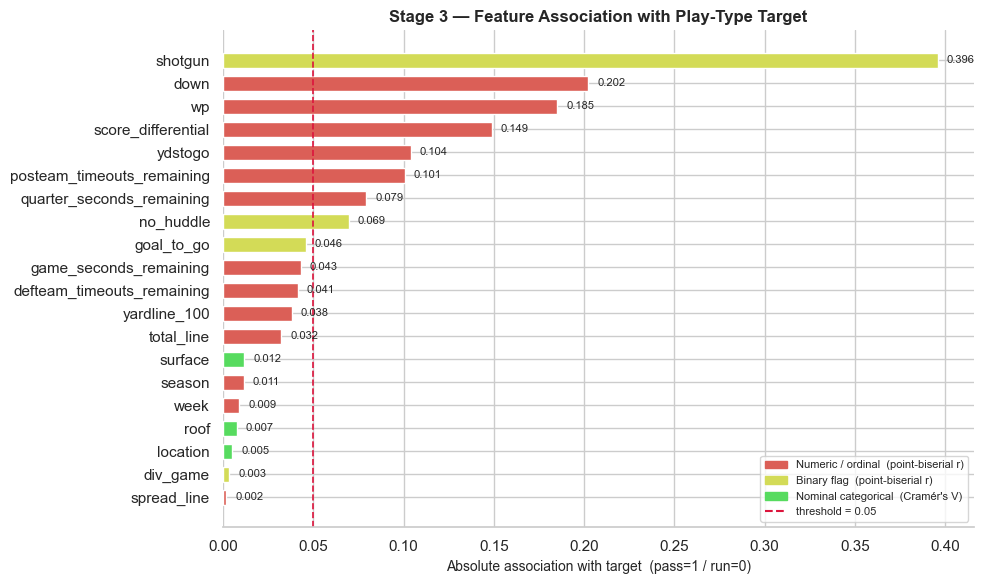

In [10]:
palette = sns.color_palette(PLOT_PALETTE)

fig, ax = plt.subplots(figsize=(10, 6))

plot_df = assoc_df.copy().sort_values("abs_assoc", ascending=True) #sort values

# assign colors
color_map = {"numeric": palette[0], "binary": palette[1], "categorical": palette[2]}
colors = plot_df["type"].map(color_map)

# create horizontal bar chart
bars = ax.barh(plot_df["feature"], plot_df["abs_assoc"],
               color=colors, edgecolor="white", height=0.65)
ax.axvline(ASSOCIATION_THRESHOLD, color="crimson", linestyle="--", linewidth=1.2)

# add values and labels next to each bar
for bar, val in zip(bars, plot_df["abs_assoc"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=8)

# create custom legend for type and treshold
legend_handles = [
    Patch(color=palette[0], label="Numeric / ordinal  (point-biserial r)"),
    Patch(color=palette[1], label="Binary flag  (point-biserial r)"),
    Patch(color=palette[2], label="Nominal categorical  (Cramér's V)"),
    plt.Line2D([0], [0], color="crimson", linestyle="--",
               label=f"threshold = {ASSOCIATION_THRESHOLD}"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")


# set chat labens and title
ax.set_xlabel("Absolute association with target  (pass=1 / run=0)", fontsize=10)
ax.set_title("Stage 3 — Feature Association with Play-Type Target",
             fontsize=12, fontweight="bold")


ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f")) # fomrat x-axis ticks

# clean up plot borders and spacing
sns.despine(left=True)
plt.tight_layout()

plt.savefig(FIGURES_EDA / "stage3_target_association.png", dpi=PLOT_DPI, bbox_inches="tight")
plt.show()


### 3.2 — Inter-Feature Correlation

Pearson correlation matrix across all retained features. Categorical features (`location`, `roof`, `surface`) are ordinal-encoded for this matrix only.

**Why this matters:** Highly correlated predictors (|*r*| > 0.70) carry redundant information — they inflate variance in linear models and complicate feature attribution. Tree-based models are more robust to this, but it is still worth flagging.

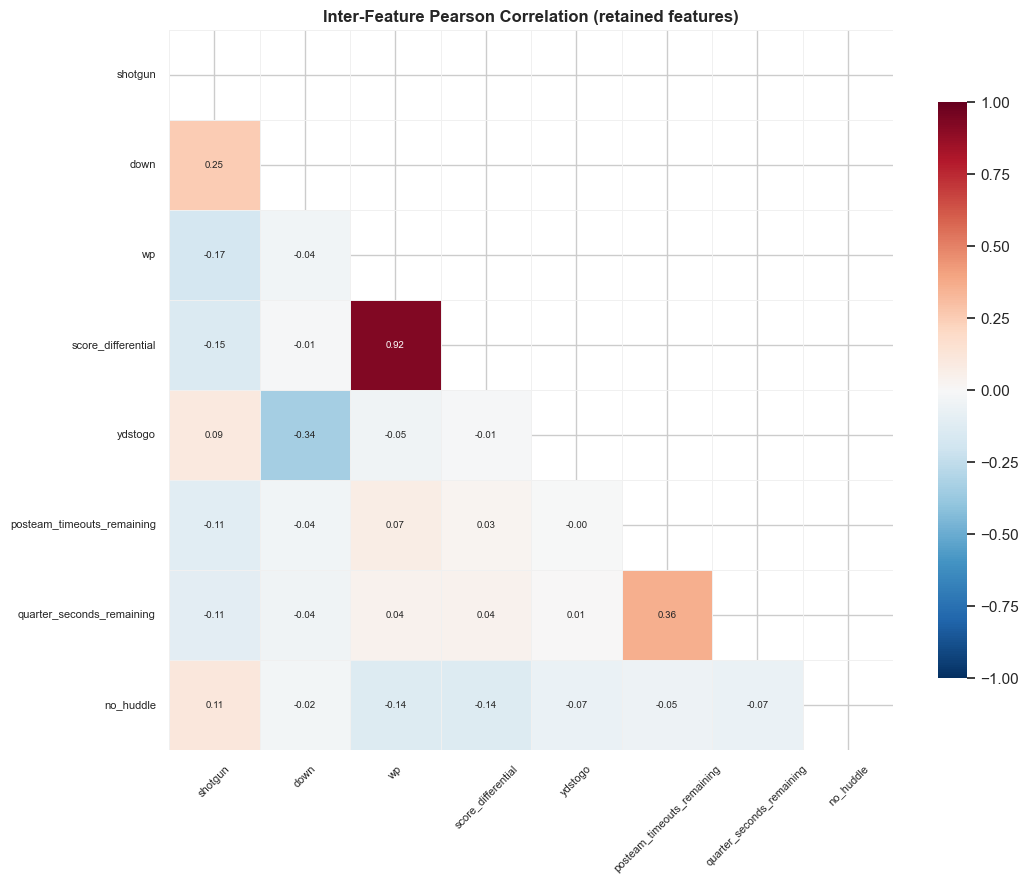

High-correlation pairs (|r| >= 0.70):
  wp                                  score_differential                  r = +0.922


In [ ]:
# ordinal-encode categoricals for correlation matrix only
df_corr = df[FEATURES_100].copy()
cat_in_final = [c for c in FEATURES_CAT if c in FEATURES_100]
if cat_in_final:
    enc = OrdinalEncoder()
    df_corr[cat_in_final] = enc.fit_transform(df_corr[cat_in_final].astype(str))

corr_matrix = df_corr.apply(pd.to_numeric, errors="coerce").corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4, linecolor="#f0f0f0",
    annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax
)

ax.set_title("Inter-Feature Pearson Correlation (retained features)",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_EDA / "stage3_feature_correlation.png", dpi=PLOT_DPI, bbox_inches="tight")
plt.show()

# flag high-correlation pairs
high_corr = []
cols_c = corr_matrix.columns.tolist()
for i in range(len(cols_c)):
    for j in range(i + 1, len(cols_c)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.70:
            high_corr.append((cols_c[i], cols_c[j], round(r, 3)))

if high_corr:
    print("High-correlation pairs (|r| >= 0.70):")
    for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a:<35} {b:<35} r = {r:+.3f}")
else:
    print("No feature pairs exceed |r| = 0.70")


### 3.3 — Variance Inflation Factor (VIF)

VIF quantifies how much the variance of a regression coefficient is inflated by collinearity. Rule of thumb: VIF > 10 = severe, VIF > 5 = warning.

`game_seconds_remaining` and `quarter_seconds_remaining` are structurally related (the former is monotonically derivable from the latter + `down`) — VIF will flag this.

In [ ]:
# ── VIF — numeric + binary features only (categoricals dropped)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in FINAL_FEATURES if c not in FEATURES_CAT]
df_vif = df[vif_cols].dropna()

vif_data = pd.DataFrame({
    "feature": vif_cols,
    "VIF": [variance_inflation_factor(df_vif.values.astype(float), i)
            for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False)

print(vif_data.to_string(index=False))

VIF_WARN = 5.0
VIF_CRIT = 10.0
flagged = vif_data[vif_data["VIF"] > VIF_WARN]
if not flagged.empty:
    print(f"\nFeatures with VIF > {VIF_WARN}:")
    print(flagged.to_string(index=False))

                   feature       VIF
                        wp 14.411429
posteam_timeouts_remaining 13.680912
                      down  5.733673
                   ydstogo  5.196022
        score_differential  4.245150
 quarter_seconds_remaining  4.081905
                   shotgun  3.372780
                 no_huddle  1.139431

Features with VIF > 5.0:
                   feature       VIF
                        wp 14.411429
posteam_timeouts_remaining 13.680912
                      down  5.733673
                   ydstogo  5.196022


### 3.4 — Final Feature Set

Features that pass all three stages:

1. Stage 1: not a post-snap outcome, play-type derivative, player/team identity, or admin column
2. Stage 2: ≤ 5% missing values
3. Stage 3: |*r*| or *V* ≥ 0.05 with the target

In [ ]:
# ── final feature set entering modelling
FINAL_FEATURES_CLEAN = [f for f in FINAL_FEATURES if f != "weather"]

print(f"Total features entering modelling: {len(FINAL_FEATURES_CLEAN)}")
print("\nNumeric / ordinal:")
for feat in FINAL_FEATURES_CLEAN:
    if feat in FEATURES_NUM:
        row = assoc_df[assoc_df["feature"] == feat].iloc[0]
        print(f"  {feat:<35} r = {row['association']:+.3f}")
print("\nBinary:")
for feat in FINAL_FEATURES_CLEAN:
    if feat in FEATURES_BIN:
        row = assoc_df[assoc_df["feature"] == feat].iloc[0]
        print(f"  {feat:<35} r = {row['association']:+.3f}")
print("\nNominal categorical:")
for feat in FINAL_FEATURES_CLEAN:
    if feat in FEATURES_CAT:
        row = assoc_df[assoc_df["feature"] == feat].iloc[0]
        print(f"  {feat:<35} V = {row['association']:.3f}")

Total features entering modelling: 8

Numeric / ordinal:
  down                                r = +0.202
  wp                                  r = -0.185
  score_differential                  r = -0.149
  ydstogo                             r = +0.104
  posteam_timeouts_remaining          r = -0.101
  quarter_seconds_remaining           r = -0.079

Binary:
  shotgun                             r = +0.396
  no_huddle                           r = +0.069

Nominal categorical:
